# Trabajo Práctico — Series Temporales

## 05 — Modelos SARIMA

**Objetivo de este notebook:** ajustar un modelo SARIMA por serie (ozono, temperatura, radiación solar), usando los órdenes de diferenciación `d`/`D` determinados en `04_estacionariedad.ipynb`, seleccionar `(p,q)(P,Q)` por grilla + AIC, diagnosticar los residuos, y pronosticar sobre un tramo de test.

**Nota sobre el volumen de datos:** el dataset completo tiene más de 200.000 observaciones horarias. Ajustar SARIMAX (un modelo de espacio de estados) con período estacional 24 sobre la serie completa, repitiendo esto para cada combinación de la grilla, es computacionalmente muy caro y no aporta nada distinto a hacerlo sobre una ventana reciente representativa. Por eso la **selección de modelo** (grilla + AIC) se hace sobre una ventana acotada. Esto es una adaptación explícita al volumen real de datos, no un atajo escondido.

Se midió el costo real antes de fijar el tamaño de la grilla: un solo ajuste SARIMAX con estacionalidad 24 tarda **~50 segundos** sobre una ventana de 1 año, pero sube a **~110 segundos** sobre 2 años (el óptimo no escala lineal). Con eso, una grilla de `(p,q)∈{0,1}` x `(P,Q)∈{0,1}` (16 combinaciones) sobre 1 año de datos, tres series, se mantiene en un orden de 40 minutos — manejable. Una grilla más fina o una ventana más larga se puede correr después si hace falta, pero ya no a ciegas.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
ordenes = json.loads((PROJECT_ROOT / "data/processed/ordenes_diferenciacion.json").read_text(encoding="utf-8"))

print(f"Filas totales: {len(datos):,}")
print(json.dumps(ordenes, indent=2))

Filas totales: 239,078
{
  "ozono_ppm": {
    "d": 0,
    "D": 1,
    "periodo_estacional": 24
  },
  "temperatura_c": {
    "d": 0,
    "D": 1,
    "periodo_estacional": 24
  },
  "radiacion_ghi_wm2": {
    "d": 0,
    "D": 1,
    "periodo_estacional": 24
  }
}


## 1. Ventanas de trabajo

- **Selección de modelo:** últimos 2 años completos disponibles, menos los últimos 7 días (que se reservan como test).
- **Test:** últimos 7 días (168 horas) de esa ventana.

In [2]:
HORAS_TEST = 24 * 7
VENTANA_SELECCION_DIAS = 365

fin_ventana = datos.index.max()
inicio_ventana = fin_ventana - pd.Timedelta(days=VENTANA_SELECCION_DIAS)
ventana = datos.loc[inicio_ventana:fin_ventana]

train = ventana.iloc[:-HORAS_TEST]
test = ventana.iloc[-HORAS_TEST:]

print(f"Ventana de selección: {ventana.index.min()} -> {ventana.index.max()} ({len(ventana):,} horas)")
print(f"Train: {len(train):,} horas | Test: {len(test):,} horas")

Ventana de selección: 2024-08-27 09:00:00+00:00 -> 2025-08-27 09:00:00+00:00 (8,713 horas)
Train: 8,545 horas | Test: 168 horas


## 2. Funciones auxiliares

`grid_search_sarima` recorre una grilla chica de `(p,q)` x `(P,Q)` (con `d`/`D`/`s` fijos, ya determinados en el notebook anterior), ajusta cada combinación y se queda con la de menor AIC. `diagnosticar_residuos` grafica residuo + ACF/PACF + p-valores de Ljung-Box. `evaluar_pronostico` calcula MSE/MAE/RMSE/MAPE.

In [3]:
def grid_search_sarima(serie_train, d, D, s, p_max=1, q_max=1, P_max=1, Q_max=1):
    mejor_aic = np.inf
    mejor_orden = None
    mejor_modelo = None
    resultados = []

    combinaciones = list(itertools.product(range(p_max + 1), range(q_max + 1), range(P_max + 1), range(Q_max + 1)))
    for i, (p, q, P, Q) in enumerate(combinaciones, start=1):
        t0 = time.time()
        try:
            modelo = SARIMAX(
                serie_train, order=(p, d, q), seasonal_order=(P, D, Q, s),
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False)
            resultados.append((p, d, q, P, D, Q, s, modelo.aic))
            if modelo.aic < mejor_aic:
                mejor_aic = modelo.aic
                mejor_orden = (p, d, q, P, D, Q, s)
                mejor_modelo = modelo
            print(f"  [{i}/{len(combinaciones)}] ({p},{d},{q})({P},{D},{Q},{s}) -> AIC={modelo.aic:.1f}  ({time.time()-t0:.0f}s)")
        except Exception as exc:
            print(f"  [{i}/{len(combinaciones)}] ({p},{d},{q})({P},{D},{Q},{s}) -> FALLÓ: {exc}")
            continue

    tabla = pd.DataFrame(resultados, columns=["p", "d", "q", "P", "D", "Q", "s", "AIC"]).sort_values("AIC")
    return mejor_orden, mejor_modelo, tabla


def diagnosticar_residuos(modelo, nombre):
    resid = modelo.resid

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(resid)
    axes[0].set_title(f"Residuos — {nombre}")
    plot_acf(resid.dropna(), lags=48, ax=axes[1])
    axes[1].set_title("ACF de residuos")

    lb = acorr_ljungbox(resid.dropna(), lags=30)
    axes[2].plot(lb.index, lb["lb_pvalue"], marker="o")
    axes[2].axhline(0.05, color="red", linestyle="--")
    axes[2].set_title("p-valores Ljung-Box")
    plt.tight_layout()
    plt.show()

    print(f"Ljung-Box: {(lb['lb_pvalue'] > 0.05).sum()}/{len(lb)} lags sin autocorrelación significativa (p>0.05)")


def evaluar_pronostico(real, pronosticado, nombre):
    real = np.asarray(real)
    mae = mean_absolute_error(real, pronosticado)
    rmse = mean_squared_error(real, pronosticado) ** 0.5

    # El MAPE divide por el valor real: con series que pasan por valores muy
    # cercanos a cero (el ozono de noche, por ejemplo) el porcentaje explota
    # y deja de ser informativo. Se reporta como no disponible en ese caso
    # en vez de mostrar un número sin sentido.
    if np.min(np.abs(real)) < 1e-3:
        mape = None
        print(f"[{nombre}] MAE={mae:.5f}  RMSE={rmse:.5f}  MAPE=no disponible (hay valores reales ~0)")
    else:
        mape = mean_absolute_percentage_error(real, pronosticado)
        print(f"[{nombre}] MAE={mae:.5f}  RMSE={rmse:.5f}  MAPE={mape:.2%}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

## 3. Ajuste por serie

Para cada una de las tres series: grilla + AIC sobre el train de la ventana de selección, mejor modelo, diagnóstico de residuos, pronóstico sobre el test (7 días) y métricas de error.


ozono_ppm


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [1/16] (0,0,0)(0,1,0,24) -> AIC=-52694.6  (1s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [2/16] (0,0,0)(0,1,1,24) -> AIC=-53479.6  (5s)


...

  [14/16] (1,0,1)(0,1,1,24) -> AIC=-66329.3  (30s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [15/16] (1,0,1)(1,1,0,24) -> AIC=-64800.1  (22s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  [16/16] (1,0,1)(1,1,1,24) -> AIC=-66485.6  (24s)
Mejor orden (p,d,q)(P,D,Q,s): (1, 0, 1, 1, 1, 1, 24)
 p  d  q  P  D  Q  s           AIC
 1  0  1  1  1  1 24 -66485.563813
 1  0  1  0  1  1 24 -66329.277661
 1  0  0  1  1  1 24 -66088.004022
 1  0  0  0  1  1 24 -65853.766187
 1  0  1  1  1  0 24 -64800.087380


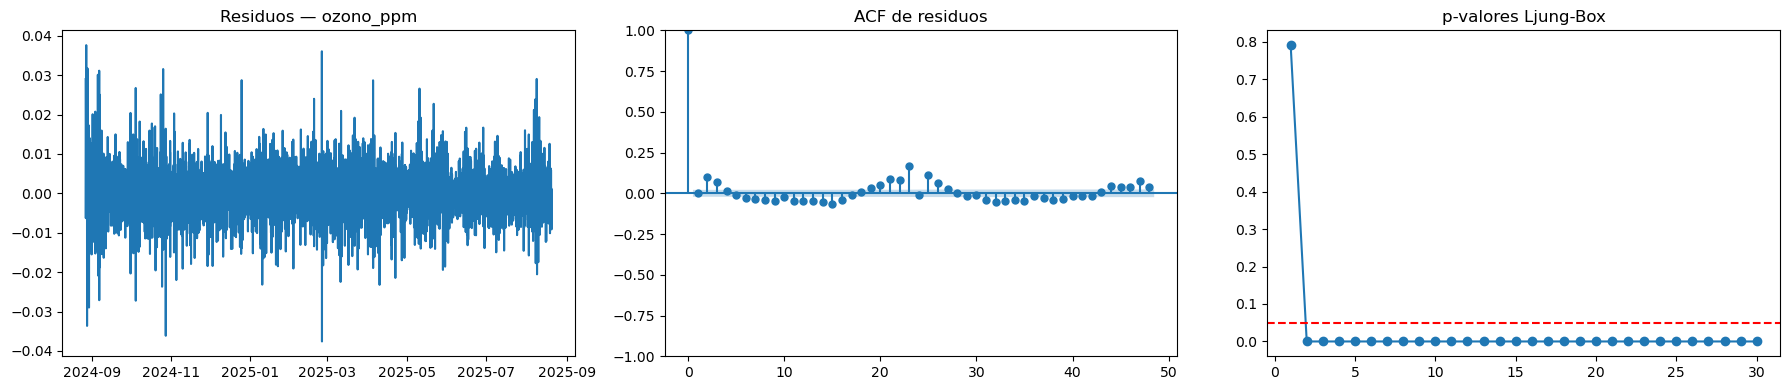

Ljung-Box: 1/30 lags sin autocorrelación significativa (p>0.05)
[ozono_ppm] MAE=0.01105  RMSE=0.01378  MAPE=no disponible (hay valores reales ~0)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


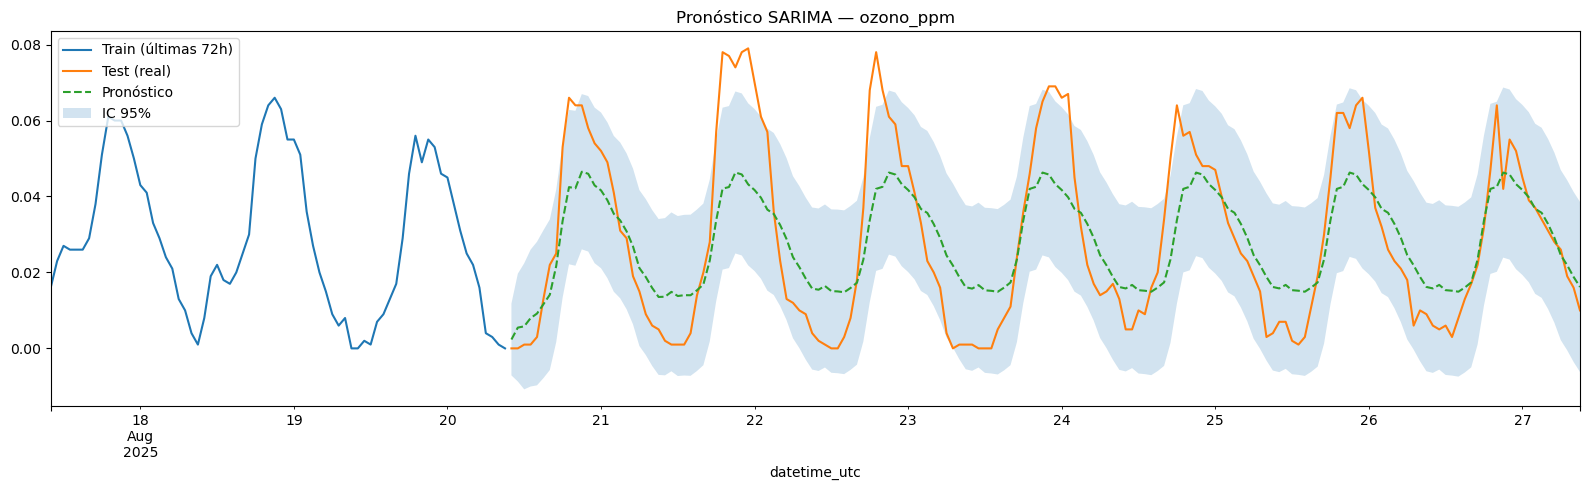


temperatura_c


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [1/16] (0,0,0)(0,1,0,24) -> AIC=34813.1  (0s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [2/16] (0,0,0)(0,1,1,24) -> AIC=33878.9  (3s)


...

  [14/16] (1,0,1)(0,1,1,24) -> AIC=18933.2  (7s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [15/16] (1,0,1)(1,1,0,24) -> AIC=20468.4  (5s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [16/16] (1,0,1)(1,1,1,24) -> AIC=18876.2  (10s)
Mejor orden (p,d,q)(P,D,Q,s): (1, 0, 1, 1, 1, 1, 24)
 p  d  q  P  D  Q  s          AIC
 1  0  1  1  1  1 24 18876.157030
 1  0  1  0  1  1 24 18933.170011
 1  0  0  1  1  1 24 19031.141008
 1  0  0  0  1  1 24 19097.443465
 1  0  1  1  1  0 24 20468.397861


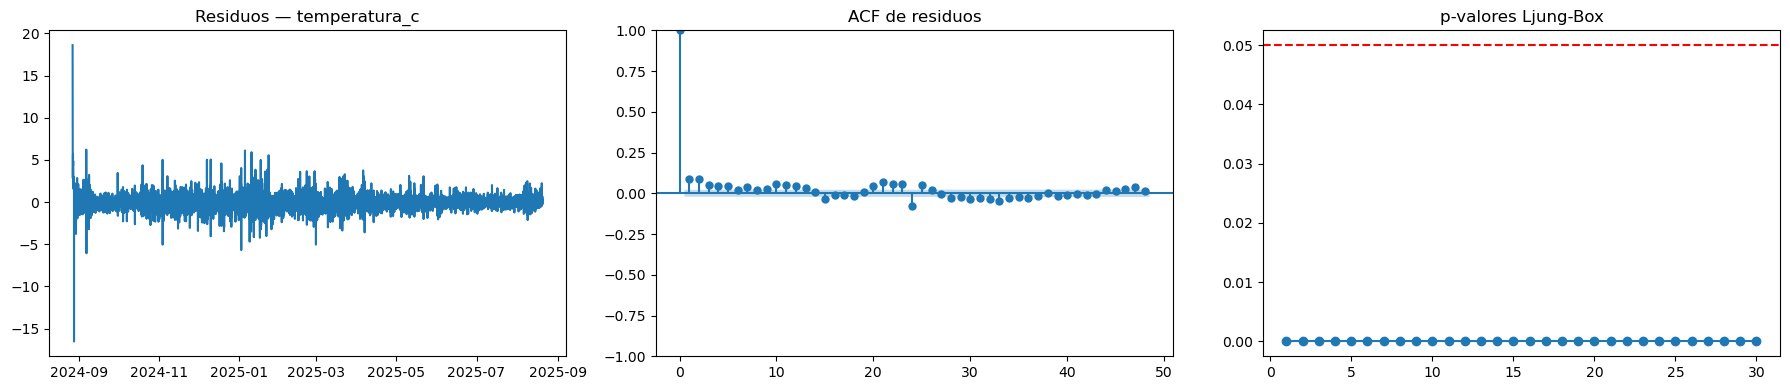

Ljung-Box: 0/30 lags sin autocorrelación significativa (p>0.05)
[temperatura_c] MAE=2.04082  RMSE=2.51183  MAPE=8.49%


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


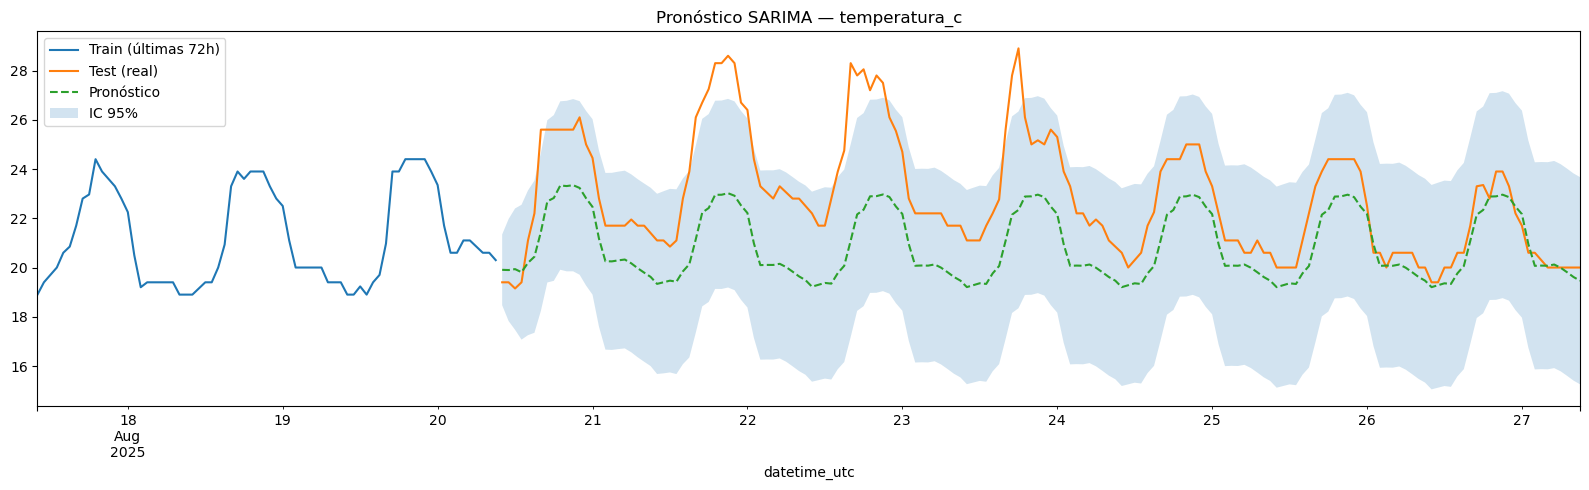


radiacion_ghi_wm2


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [1/16] (0,0,0)(0,1,0,24) -> AIC=105568.9  (0s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [2/16] (0,0,0)(0,1,1,24) -> AIC=104350.4  (3s)


...

  [14/16] (1,0,1)(0,1,1,24) -> AIC=91071.3  (9s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [15/16] (1,0,1)(1,1,0,24) -> AIC=92030.9  (7s)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  [16/16] (1,0,1)(1,1,1,24) -> AIC=91068.3  (20s)
Mejor orden (p,d,q)(P,D,Q,s): (1, 0, 1, 1, 1, 1, 24)
 p  d  q  P  D  Q  s          AIC
 1  0  1  1  1  1 24 91068.343759
 1  0  1  0  1  1 24 91071.313206
 1  0  1  1  1  0 24 92030.923358
 1  0  0  1  1  1 24 92599.181411
 1  0  0  0  1  1 24 92624.392140


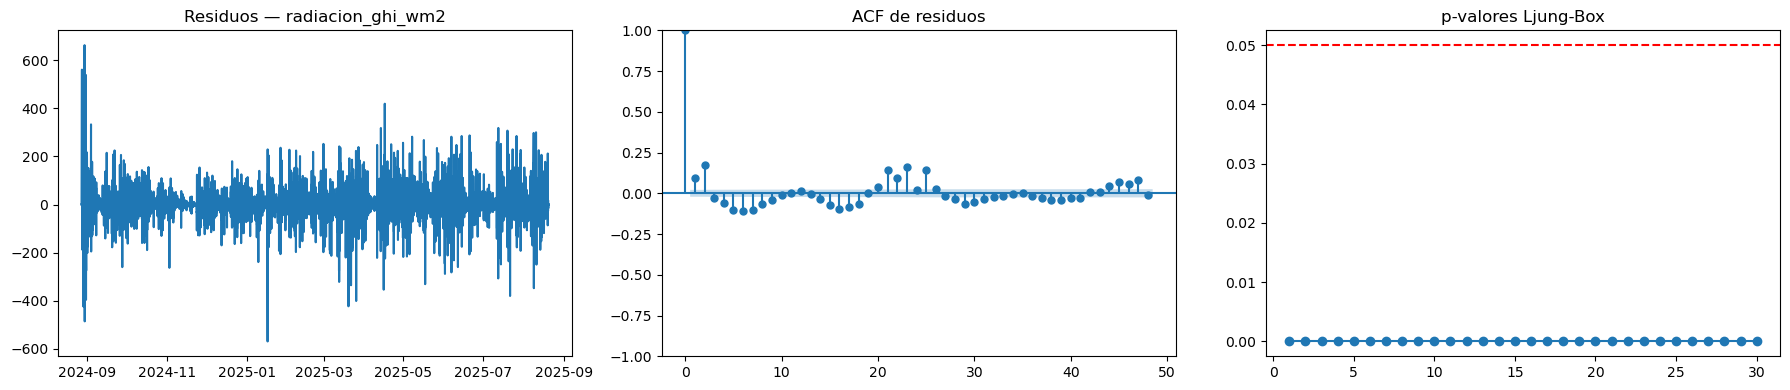

Ljung-Box: 0/30 lags sin autocorrelación significativa (p>0.05)
[radiacion_ghi_wm2] MAE=34.86503  RMSE=67.39912  MAPE=no disponible (hay valores reales ~0)


c:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\ldi2\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


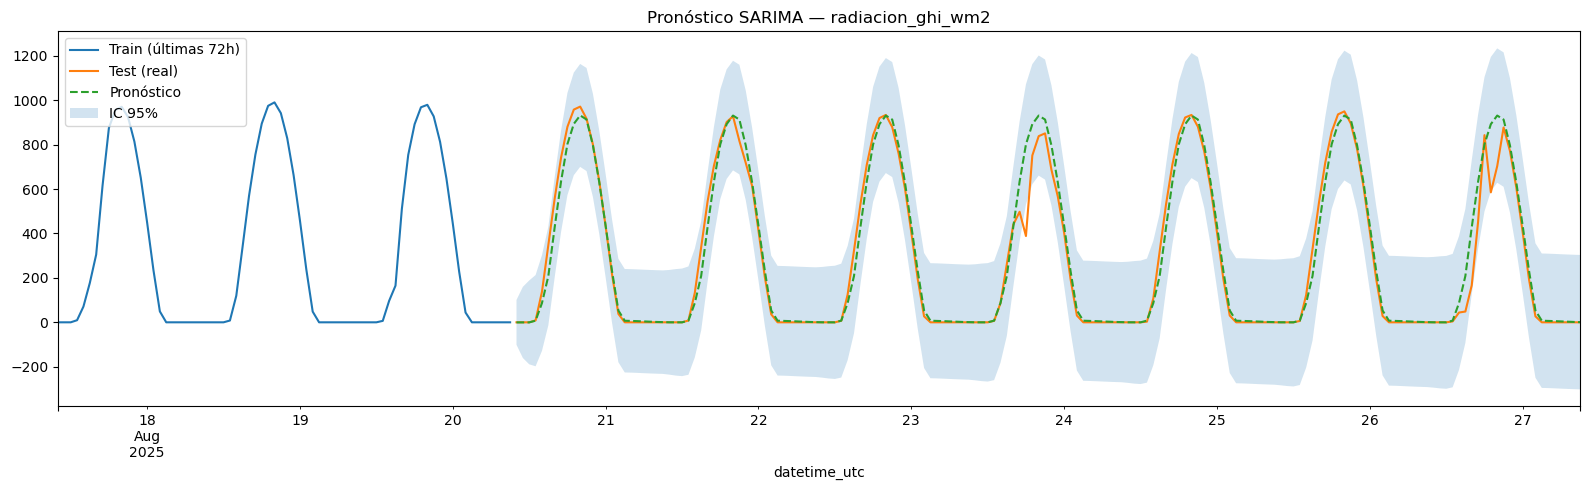

In [4]:
resultados_por_serie = {}

for col in datos.columns:
    print(f"\n{'='*60}\n{col}\n{'='*60}")
    d, D, s = ordenes[col]["d"], ordenes[col]["D"], ordenes[col]["periodo_estacional"]

    orden, modelo, tabla_aic = grid_search_sarima(train[col], d=d, D=D, s=s)
    print(f"Mejor orden (p,d,q)(P,D,Q,s): {orden}")
    print(tabla_aic.head(5).to_string(index=False))

    diagnosticar_residuos(modelo, col)

    pronostico = modelo.get_forecast(steps=HORAS_TEST)
    # El train no tiene una frecuencia regular garantizada (se descartaron
    # huecos largos en la limpieza), así que statsmodels no siempre puede
    # devolver el pronóstico con índice de fechas — se asigna a mano el
    # índice real de las horas de test, que es exactamente lo que se pidió
    # pronosticar (steps=HORAS_TEST == len(test)).
    media_pronostico = pd.Series(pronostico.predicted_mean.values, index=test.index)
    intervalo = pd.DataFrame(pronostico.conf_int().values, index=test.index, columns=["inf", "sup"])

    metricas = evaluar_pronostico(test[col].values, media_pronostico.values, col)

    fig, ax = plt.subplots(figsize=(16, 5))
    train[col].iloc[-72:].plot(ax=ax, label="Train (últimas 72h)")
    test[col].plot(ax=ax, label="Test (real)")
    media_pronostico.plot(ax=ax, label="Pronóstico", linestyle="--")
    ax.fill_between(intervalo.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1], alpha=0.2, label="IC 95%")
    ax.set_title(f"Pronóstico SARIMA — {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    resultados_por_serie[col] = {"orden": orden, "modelo": modelo, "metricas": metricas}

## 4. Resumen final

In [5]:
resumen = pd.DataFrame({
    col: {"orden_sarima": str(resultados_por_serie[col]["orden"]), **resultados_por_serie[col]["metricas"]}
    for col in datos.columns
}).T
print(resumen)

print("\nProyecto listo para continuar con 06_var.ipynb (modelo VAR conjunto de las tres series).")

                             orden_sarima        MAE       RMSE      MAPE
ozono_ppm          (1, 0, 1, 1, 1, 1, 24)   0.011052   0.013785      None
temperatura_c      (1, 0, 1, 1, 1, 1, 24)   2.040817   2.511834  0.084917
radiacion_ghi_wm2  (1, 0, 1, 1, 1, 1, 24)  34.865034  67.399116      None

Proyecto listo para continuar con 06_var.ipynb (modelo VAR conjunto de las tres series).
